In [43]:
import numpy as np
from __future__ import annotations

EPSILON = 1e-6

class Tensor():
  _compute_grad = True # global flag

  def __init__(self, data, require_grad = False):
    self.data = Tensor._clean_inputs(data)
    self.require_grad = require_grad
    self._hist = None # stores the operation and inputs that generate this tensor
    self.grad = None # Tensor gradients

  @staticmethod
  def _clean_inputs(data):
    """Clean input for the __init__ func"""
    if isinstance(data, (int, float)): return np.array([data]).astype(np.float32)
    if isinstance(data, list): return np.array(data).astype(np.float32)
    if isinstance(data, (Tensor, Parameter)): return data.data.copy()
    if isinstance(data, np.ndarray): return data.astype(np.float32)
    raise TypeError(f"Unexpected data type: {type(data)}, {data}")

  @property
  def shape(self):
    return self.data.shape

  @property
  def size(self):
    return self.data.size

  def __repr__(self) -> str:
    s = f"Tensor( "
    if self.size < 15:
      s+= str(self.vdata) + ""
    s+= f" shape={self.shape}"
    if self.require_grad:
      s+= f" require_grad=True"
    if self._hist is not None:
      s+= f" grad_fn={self._hist.op.__name__}"
    s+=" )"
    return s

  @property
  def vdata(self):
    """View the numpy data"""
    return np.round(self.data, 2)

  @staticmethod
  def _ensure_Tensor(data):
    if not isinstance(data, Tensor):
      return Tensor(data)
    return data # Don't make copy if data is a tensor

  def to_list(self):
    return self.data.tolist()

  def item(self):
    if self.size != 1:
      raise ValueError(f"This function on works for size == 1. Current size: {self.size}")
    return float(self.data.sum())

  def __add__(self, other):
    return Add.apply(self, Tensor._ensure_Tensor(other))

  def __radd__(self, other):
    return Add.apply(Tensor._ensure_Tensor(other), self)

  def __sub__(self, other):
    return Sub.apply(self, Tensor._ensure_Tensor(other))

  def __rsub__(self, other):
    return Sub.apply(Tensor._ensure_Tensor(other), self)

  def __mul__(self, other):
    return Mult.apply(self, Tensor._ensure_Tensor(other))

  def __rmul__(self, other):
    return Mult.apply(Tensor._ensure_Tensor(other), self)

  def __truediv__(self, other):
    return self * Tensor._ensure_Tensor(other).reciprocal()

  def __rtruediv__(self, other):
    return Tensor._ensure_Tensor(other) * self.reciprocal()

  def __pow__(self, other):
    return Power.apply(self, other)

  def reciprocal(self):
    return Reciprocal.apply(self)

  def __matmul__(self, other):
    return MatMult.apply(self, Tensor._ensure_Tensor(other))

  def __rmatmul__(self, other):
    return MatMult.apply(Tensor._ensure_Tensor(other), self)
  
  def __getitem__(self, items):
    return Slice.apply(self, items)

  def sum(self, keepdims=True):
    return Sum.apply(self, keepdims)

  def flatten(self, batch=False):
    return Flatten.apply(self, batch)

  def reshape(self, shape):
    return Reshape.apply(self, shape)

  @staticmethod
  def _undo_broadcast(tensor: Tensor, grad: np.ndarray) -> np.ndarray:
    if grad.shape == tensor.shape:
      return grad

    # reduce until same dimensions
    while len(grad.shape) > len(tensor.shape):
      grad = grad.sum(axis=0)

    # undo the dims that were collapsed to 1
    for n in range(len(grad.shape)):
      if tensor.shape[n] != grad.shape[n]:
        grad = grad.sum(axis=n, keepdims=True)

    return grad

  def backward(self, draw=False):
    '''
    draw: print out the grad during backpass
    '''
    if not Tensor._compute_grad or self._hist is None:
      return

    if self.grad is None:
      if self.size != 1:
        raise ValueError(f"Current Tensor size must be 1 to start back prop. Size: {self.size}")
      self.grad = Tensor(np.ones_like(self.data, dtype=np.float32))

    sorted_nodes = []
    def topo_sort(node: Tensor, visited: set, sorted_nodes: list):
      if id(node) in visited:
        return
      visited.add(id(node))

      if node._hist is None:
        sorted_nodes.append(node)
        return

      for node_inp in node._hist.inp:
        if isinstance(node_inp, Tensor):
          topo_sort(node_inp, visited, sorted_nodes)
      sorted_nodes.append(node)

    topo_sort(self, set(), sorted_nodes)
    sorted_nodes.reverse()

    # The Logic:
    # For every node, you update the .grad of its *input nodes*
    for node in sorted_nodes:
      if node._hist == None:
        continue
      node_grad = node.grad.data
      grads = node._hist.op.backward(node._hist, node_grad)

      for n, g in zip(node._hist.inp, grads):
        if n.grad is None:
          n.grad = Tensor(np.zeros_like(n.data, dtype=np.float32))
        # undo broadcasting
        n.grad.data += Tensor._undo_broadcast(n, g.data)

      node._hist = None # remove DAG

    if draw:
      print(
          [n.grad.to_list() for n in sorted_nodes]
      )


class Function():

  def __init__(self, cls, *inp):
    self.op: Function = cls
    self.inp: tuple = inp

  @classmethod
  def apply(cls, *inp):
    """Computes forward pass and constructs DAG"""
    hist = Function(cls, *inp) # there * will unpack the var `inp`
    res: Tensor = cls.forward(*inp)
    if Function._gen_graph(inp):
      # Note res.require_grad for the intermediates does not need to be True
      res._hist = hist
    return res

  @staticmethod
  def _gen_graph(inp: tuple) -> bool:
    if not Tensor._compute_grad:
      return False

    for i in inp:
      if isinstance(i, (Tensor, Parameter)) and (i.require_grad or i._hist is not None):
        return True

    return False

  @staticmethod
  def forward() -> Tensor:
    raise NotImplementedError

  @staticmethod
  def backward(hist, grad: np.ndarray) -> tuple: # always return a tuple for consistency
    raise NotImplementedError

# -------------------------------------------------
# Basic Functions
# -------------------------------------------------

class Add(Function):
  @staticmethod
  def forward(x, y):
    return Tensor(x.data + y.data)

  @staticmethod
  def backward(hist, grad): # this will not have access to self.inp
    return Tensor(grad), Tensor(grad)

class Sub(Function):
  @staticmethod
  def forward(x, y):
    return Tensor(x.data - y.data)

  @staticmethod
  def backward(hist, grad):
    return Tensor(grad), Tensor(-1.0 * grad) # -np.array creates copy

class Mult(Function):
  @staticmethod
  def forward(x, y):
    return Tensor(x.data * y.data)

  @staticmethod
  def backward(hist, grad):
    x, y = hist.inp
    return Tensor(y.data * grad), Tensor(x.data * grad)

class Reciprocal(Function):
  @staticmethod
  def forward(x):
    return Tensor(float(1) / x.data)

  @staticmethod
  def backward(hist, grad: np.ndarray):
    x, = hist.inp
    return ( Tensor(-grad / (x.data**2)) ,)

class Power(Function):
  @staticmethod
  def forward(x, p):
    if not isinstance(p, (int, float)):
      raise TypeError(f"Invalid type of exponent ({type(p)})")
    return Tensor(x.data ** p)

  @staticmethod
  def backward(hist, grad) -> tuple:
    x, p = hist.inp
    return Tensor(grad * float(p) * x.data ** (p-1)),

class MatMult(Function):
  @staticmethod
  def forward(x, y):
    return Tensor(x.data @ y.data)

  @staticmethod
  def backward(hist, grad):
    x, y = hist.inp

    x_axis = list(range(len(x.shape)))
    x_axis[-2], x_axis[-1] = x_axis[-1], x_axis[-2]

    y_axis = list(range(len(y.shape)))
    y_axis[-2], y_axis[-1] = y_axis[-1], y_axis[-2]

    grad_x = grad @ np.transpose(y.data, axes=y_axis)
    grad_y = np.transpose(x.data, axes=x_axis) @ grad

    return Tensor(grad_x), Tensor(grad_y)

class Sum(Function):
  @staticmethod
  def forward(x, keepdims): # TODO: support sum over certain dims
    return Tensor(x.data.sum(keepdims=keepdims))

  @staticmethod
  def backward(hist, grad: np.ndarray) -> tuple:
    x = hist.inp[0]
    return Tensor(np.ones_like(x, dtype=np.float32) * grad),

class Flatten(Function):
  @staticmethod
  def forward(x: Tensor, batch = False):
    if batch:
      batch_size = x.shape[0]
      return Tensor(x.data.reshape(batch_size, -1))
    return Tensor(x.data.reshape(-1))

  @staticmethod
  def backward(hist, grad: np.ndarray):
    x = hist.inp[0]
    return Tensor(grad.reshape(x.data.shape)),

class Combine(Function):
  @staticmethod
  def forward(*x: tuple[Tensor]) -> Tensor:
    # for images, x is shape (1, 1, 1)
    # for now the axis of concatination doesn't matter bc it will be reshaped later
    d = [n.data for n in x]
    return Tensor(np.concatenate(d, axis=0))

  @staticmethod
  def backward(hist, grad: np.ndarray) -> tuple:
    inp = hist.inp
    l = np.cumsum([n.shape[0] for n in inp])[:-1]
    return [Tensor(n) for n in np.split(grad, l, axis=0)]

# TERRIBLE ineffecient
class Combine1(Function):
  @staticmethod
  def forward(*x: tuple[Tensor]) -> Tensor:
    # for images, x is shape (1, 1, 1)
    # for now the axis of concatination doesn't matter bc it will be reshaped later
    d = [n.data for n in x]
    return Tensor(np.concatenate(d, axis=1))

  @staticmethod
  def backward(hist, grad: np.ndarray) -> tuple:
    inp = hist.inp
    l = np.cumsum([n.shape[0] for n in inp])[:-1]
    return [Tensor(n) for n in np.split(grad, l, axis=1)]

class Reshape(Function):
  @staticmethod
  def forward(x, shape) -> Tensor:
    return Tensor(x.data.reshape(shape))

  @staticmethod
  def backward(hist, grad: np.ndarray) -> tuple:
    x, _ = hist.inp
    return Tensor(grad.reshape(x.shape)),

class Slice(Function):
  @staticmethod
  def forward(x, sli):
    return Tensor(x.data[sli])

  @staticmethod
  def backward(hist, grad):
    x, sli = hist.inp
    grad_x = np.zeros_like(x.data)
    grad_x[sli] = grad
    return Tensor(grad_x),

# -------------------------------------------------
# Activation Functions
# -------------------------------------------------

class Relu(Function):
  @staticmethod
  def forward(x):
    return Tensor(np.maximum(0.0, x.data))

  @staticmethod
  def backward(hist, grad):
    x, = hist.inp
    mask = x.data > 0
    return Tensor(grad * mask),

def relu(x):
  return Relu.apply(x)

# -------------------------------------------------
# Losses
# -------------------------------------------------

def mean(x: Tensor, axes = None):
  # TODO: make mean work over certain dims
  return x.sum() / x.size

def mse(y_true, y_pred: Tensor) -> Tensor:
  y_true = Tensor._ensure_Tensor(y_true)
  return mean( (y_true - y_pred)**2 )

# -------------------------------------------------
# Layers
# -------------------------------------------------

class Parameter(Tensor):

  def __init__(self, data):
    super().__init__(data, require_grad=True)

class Module():
  def parameters(self):
    params = []
    for val in self.__dict__.values():
      if isinstance(val, Parameter):
        params.append(val)
      elif isinstance(val, Tensor): # I need this right? no grad update needed but needs to be there to clear grads
        params.append(val)
      elif isinstance(val, list): # should be recurrsive
        for item in val:
          if isinstance(item, (Parameter, Tensor)):
            params.append(item)
      elif isinstance(val, Module): # will be true if Module is a subclass at least
        params.extend(val.parameters())
    return params

  def __call__(self, x):
    return self.forward(x)

class Linear(Module):

  def __init__(self, in_features, out_features, bias=True):
    self.in_features = in_features
    self.out_features = out_features
    self.W = Parameter(np.random.normal(0, np.std(2/in_features), (out_features, in_features)))
    self.bias = bias
    if bias:
      self.b = Parameter(np.zeros((out_features, 1)))

  def forward(self, x):
    if self.bias:
      return self.W @ x + self.b
    return self.W @ x

class Conv(Module):
  """For images: h,w,d"""

  def __init__(self, in_channels: int, out_channels: int, kernal_size: int, bias=True):
    self.kernal_size = kernal_size
    self.in_channels = in_channels
    self.out_channels = out_channels

    #For now just get it to work with one filter
    self.f = [Parameter(
        np.random.normal(0, 1, (self.in_channels, self.kernal_size, self.kernal_size)) # TODO: set up He initialization
    ) for n in range(self.out_channels)]

    self.bias = bias
    if self.bias:
      self.b = Parameter(np.array([0])) # I believe all the operations get the same bias added to them

  def forward(self, img: Tensor):
    # Note you don't need Slicing (yet) for proper differentiation
    # Remember the learnable parameters are the filters, not the image you're slicing for the convs!

    #  Hadamard product followed by sum! what what you do for each filter.
    n = self.kernal_size
    batch_dim, d, w, h = img.shape

    o_w = (w-n) + 1
    o_h = (h-n) + 1

    res_fin = []
    
    for f in self.f: # iterate through all the filters
      res_fil = []

      # Slicing img[:,0:n, 0:n]. Assuming the first dim is depth
      for i_w in range(o_w):
        for i_h in range(o_h):
          # res: Tensor
          # `f` has to come first cuz if not, the np array gonna take over the `*` operator
          # For backprop to properly work, img needs to be a Tensor that can properly track grads!!!
          res = (f * img[:, :, i_w:n+i_w, i_h:n+i_h]).sum() + (self.b if self.bias else 0)
          res_fil.append(res) # remember: res is one number
      res_fin.append(concat(*res_fil).reshape((-1, 1, o_w, o_h)))
    return concat1(*res_fin)

# -------------------------------------------------
# Util Funcs
# -------------------------------------------------

def concat(*x: tuple[Tensor]):
  # Note, this is not yet a fully functional concat func but for now it works
  return Combine.apply(*x)

def concat1(*x: tuple[Tensor]):
  # Note, this is not yet a fully functional concat func but for now it works
  return Combine1.apply(*x)

# -------------------------------------------------
# Optimizers
# -------------------------------------------------

class Optimizer():
  def __init__(self, parameters, lr):
    self.parameters = parameters
    self.lr = lr

  def zero_grad(self):
    for p in self.parameters:
      p.grad = None

  def step(self):
    raise NotImplementedError

class SGD(Optimizer):

  def __init__(self, parameters, lr):
    super().__init__(parameters, lr)

  def step(self):
    for p in self.parameters:
      if p.require_grad:
        if p.grad == None:
          raise ValueError("Parameter does not have gradients to do the update")
        p.data -= p.grad.data * self.lr


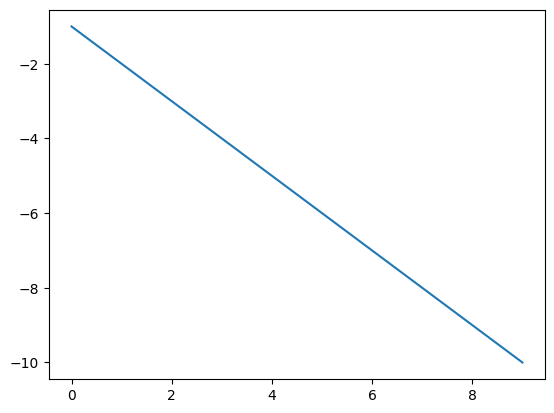

In [44]:
class ImageLayer(Module):

  def __init__(self):
    self.conv1 = Conv(1, 10, 3, bias=True)
    self.conv2 = Conv(10, 5, 3, bias=True)
    self.conv3 = Conv(5, 3, 3, bias=True) # shape=(1452,)
    self.l1 = Linear(1200, 100, bias=True)
    self.l2 = Linear(100, 1, bias=True)

  def forward(self, x):
    x = self.conv1(x)
    x = relu(x)
    x = self.conv2(x)
    x = relu(x)
    x = self.conv3(x)
    x = x.flatten(True)
    x = x.reshape((-1,1200, 1)) # for proper matrix mult in lin layer
    x = self.l1(x)
    x = relu(x)
    x = self.l2(x)
    return x

model = ImageLayer()
optimizer = SGD(model.parameters(), lr=1)

import matplotlib.pyplot as plt

losses = []
sample_img = Tensor(
    np.random.normal(0, 1, (2, 1, 26, 26))
)

for epoch in range(10):
    optimizer.zero_grad()
    y_pred = model(sample_img)
    loss = (y_pred - np.ones_like(y_pred.data)).sum()
    losses.append(loss.item())
    loss.backward()
    optimizer.step()

plt.plot(losses)

In [36]:
losses

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

In [ ]:
from tensorflow.keras.datasets import mnist
# Load the dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
y_train
mask = y_train == 1
Xt = X_train[mask][0:6000, :, :] # only get 6,000 true and false
Xf = X_train[~mask][0:6000, :, :]
Yt = y_train[mask][0:6000]
Yf = np.zeros_like(y_train[~mask][0:6000])

X = np.concat([Xt, Xf])
Y = np.concat([Yt, Yf])

In [ ]:
x = Tensor(np.ones((2,2)))
x.flatten()

Tensor( [1. 1. 1. 1.] shape=(4,) )

In [86]:
type(sample_img)

__main__.Tensor

In [ ]:
losses = []

for _ in range(1):
  for n in range(X.shape[0]):
    optimizer.zero_grad()
    img_inp = Tensor(X[n,:,:].reshape(1, 28, 28))
    res = model(img_inp)

    y_true = Tensor(np.array([[float(Y[n])]]))
    loss = mse(float(Y[n]), res)
    losses.append(loss.item())
    loss.backward()
    optimizer.step()
    break

AttributeError: 'NoneType' object has no attribute 'data'

In [ ]:
np.random.seed(42)

z = np.random.normal(0,1, (3,1))

a1 = Tensor(1, require_grad=True)
a2 = Tensor(2, require_grad=True)

b1 = a1+a2
b2 = a1+a2
b3 = Tensor(4, require_grad=True)

c1 = b1+b2

d1 = c1/b3
Tensor._compute_grad = True
d1.backward(True)

[[1.0], [6.0], [-0.375], [0.25], [0.25], [0.25], [0.5], [0.5]]


In [ ]:
a1.grad

Tensor( [0.5] shape=(1,) )

In [ ]:
class SimpleModel(Module):
  def __init__(self):
    self.l1 = Linear(10, 5, bias=True)
    self.l2 = Linear(5, 10, bias=True)

  def forward(self, x):
    x = self.l1(x)
    x = relu(x)
    x = self.l2(x)
    return x

model = SimpleModel()
optimizer = SGD(model.parameters(), lr=1)

data = np.random.normal(1, 0.1, (5, 10,1)) # 5 batches
# data = np.ones((5, 10,1)) # 5 batches
y_true = (data*4)**2 + 26

In [ ]:
y_true.shape

(5, 10, 1)

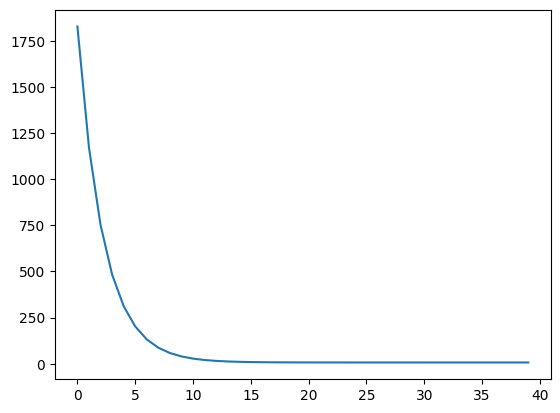

In [ ]:
import matplotlib.pyplot as plt

losses = []
# Train Loop
for n in range(40):
  optimizer.zero_grad()
  y_pred = model(data)
  loss = mse(y_true, y_pred)
  losses.append(loss.item())
  loss.backward()
  optimizer.step()

plt.plot(losses)

In [ ]:
losses[-1]

6.6175606344785685

In [ ]:
res = model(data)

In [ ]:
[bytes([n]) for n in range(256)]

[b'\x00',
 b'\x01',
 b'\x02',
 b'\x03',
 b'\x04',
 b'\x05',
 b'\x06',
 b'\x07',
 b'\x08',
 b'\t',
 b'\n',
 b'\x0b',
 b'\x0c',
 b'\r',
 b'\x0e',
 b'\x0f',
 b'\x10',
 b'\x11',
 b'\x12',
 b'\x13',
 b'\x14',
 b'\x15',
 b'\x16',
 b'\x17',
 b'\x18',
 b'\x19',
 b'\x1a',
 b'\x1b',
 b'\x1c',
 b'\x1d',
 b'\x1e',
 b'\x1f',
 b' ',
 b'!',
 b'"',
 b'#',
 b'$',
 b'%',
 b'&',
 b"'",
 b'(',
 b')',
 b'*',
 b'+',
 b',',
 b'-',
 b'.',
 b'/',
 b'0',
 b'1',
 b'2',
 b'3',
 b'4',
 b'5',
 b'6',
 b'7',
 b'8',
 b'9',
 b':',
 b';',
 b'<',
 b'=',
 b'>',
 b'?',
 b'@',
 b'A',
 b'B',
 b'C',
 b'D',
 b'E',
 b'F',
 b'G',
 b'H',
 b'I',
 b'J',
 b'K',
 b'L',
 b'M',
 b'N',
 b'O',
 b'P',
 b'Q',
 b'R',
 b'S',
 b'T',
 b'U',
 b'V',
 b'W',
 b'X',
 b'Y',
 b'Z',
 b'[',
 b'\\',
 b']',
 b'^',
 b'_',
 b'`',
 b'a',
 b'b',
 b'c',
 b'd',
 b'e',
 b'f',
 b'g',
 b'h',
 b'i',
 b'j',
 b'k',
 b'l',
 b'm',
 b'n',
 b'o',
 b'p',
 b'q',
 b'r',
 b's',
 b't',
 b'u',
 b'v',
 b'w',
 b'x',
 b'y',
 b'z',
 b'{',
 b'|',
 b'}',
 b'~',
 b'\x7f',
 b'\x80',
